In [100]:
# Imports

# Standard library
import joblib

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, roc_auc_score

## Loading Processed Datasets

In [ ]:
X_train = pd.read_parquet('../data/processed/X_train_processed.parquet', engine='fastparquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet', engine='fastparquet').squeeze()
X_test = pd.read_parquet('../data/processed/X_test_processed.parquet', engine='fastparquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet', engine='fastparquet').squeeze()


In [ ]:
# 2. Train/Validation Split (on the training set!)
# we want to keep the test set completely separate until the very end, so we only split the training set into a smaller training set and a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [64]:
len(X_train)

3199998

## Inspecting Class Imbalance

In [65]:
y_train.value_counts()

target
False    3085084
True      114914
Name: count, dtype: int64

In [66]:
y_train.value_counts(normalize=True)

target
False    0.964089
True     0.035911
Name: proportion, dtype: float64

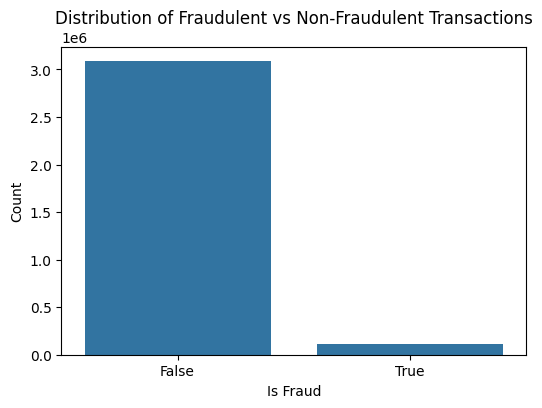

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train, data= y_train.reset_index())
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

As observed in the previous notebooks and confirmed here, the target variable exhibits a severe class imbalance: approximately 96% of transactions are non-fraudulent, while only 4% are fraudulent.  

This imbalance necessitates careful handling, as the most informative metrics in this context are **recall** and **precision**, rather than overall accuracy. In particular, **recall** is critical in fraud detection, since the primary goal is to minimize false negatives, even if some false positives are allowed.  

For now, we first train several baseline models **without any special class imbalance techniques** to evaluate their raw performance. Subsequently, we will explore techniques such as **oversampling, undersampling, and class-weight adjustments** to improve model performance on the minority class.

## Baseline Model Training and Evaluation

We will train several baseline models using a pipeline consisting of a **StandardScaler** for numeric columns and **one-hot encoding** for categorical variables. This approach is justified for the following reasons:

- **Low cardinality:** Each categorical feature contains approximately 4–8 categories with a relatively balanced distribution, making one-hot encoding well-suited.  
- **No ordinal relationship:** The categories do not have an inherent order (e.g., `transaction_type`, `location`), so encoding methods that impose numerical ranking, such as label encoding, could introduce misleading relationships.  
- **No need for advanced encoding techniques:** Methods like target encoding or frequency encoding are unnecessary, as they are mainly beneficial for high-cardinality features.  

Overall, one-hot encoding provides a simple and effective representation for these categorical variables without introducing unintended bias.

As baseline models, we will use **Logistic Regression**, **Random Forest**, **Extra Trees**, and **XGBoost**. We exclude **SVM**, as it generally performs poorly on datasets containing millions of entries.

In [69]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3199998 entries, 0 to 0
Data columns (total 28 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   transaction_type                     object 
 1   merchant_category                    object 
 2   location                             object 
 3   device_used                          object 
 4   time_since_last_transaction          float64
 5   spending_deviation_score             float64
 6   velocity_score                       int64  
 7   geo_anomaly_score                    float64
 8   payment_channel                      object 
 9   time_since_last_transaction_missing  int64  
 10  hour_of_day                          int32  
 11  at_night                             int64  
 12  weekday                              int32  
 13  on_weekend                           int64  
 14  log_amount                           float64
 15  high_amount_and_velocity             int64  
 16  high

In [70]:
categorical_cols = X_train.select_dtypes(include=['string', 'object']).columns.tolist()

In [13]:
categorical_cols 

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [71]:
# numerical features excluding binary features
true_numerical_cols = ["time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score", "hour_of_day", "weekday", "log_amount", "avg_transaction_amount_per_sender", "unique_receivers_per_sender", "accounts_per_device", "transactions_per_ip" ]


In [15]:
true_numerical_cols 

['time_since_last_transaction',
 'spending_deviation_score',
 'velocity_score',
 'geo_anomaly_score',
 'hour_of_day',
 'weekday',
 'log_amount',
 'avg_transaction_amount_per_sender',
 'unique_receivers_per_sender',
 'accounts_per_device',
 'transactions_per_ip']

In [72]:
preprocessing_without_scaling = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')

In [17]:
categorical_cols

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [73]:
preprocessing = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
     ('num', StandardScaler(), true_numerical_cols)
], remainder='passthrough')


### Logistic Regression

We begin with training the **Logistic Regression** model. This model requires feature scaling because it is sensitive to the magnitude of input variables, and unscaled numeric features can negatively affect performance.

In [74]:
def to_float32(X):
    return X.astype(np.float32)

to_float = FunctionTransformer(to_float32)

In [91]:
log_reg_baseline_model = make_pipeline(
    preprocessing,
    to_float,
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    )
)

In [93]:
log_reg_baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [94]:
# Save the trained model using joblib
# add little compression to reduce file size

joblib.dump(log_reg_baseline_model, '../src/models/log_reg_baseline_model.joblib', compress=3)

['../src/models/log_reg_baseline_model.joblib']

In [95]:
log_reg_baseline_model = joblib.load('../src/models/log_reg_baseline_model.joblib')

In [96]:
y_pred = log_reg_baseline_model.predict(X_val)

In [97]:
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud'])) # we only evaluate on the validation set for now, we will evaluate on the test set at the very end after we are done with all modeling and hyperparameter tuning to get an unbiased estimate of our model's performance on unseen data


c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   Not Fraud       0.96      1.00      0.98    771272
       Fraud       0.00      0.00      0.00     28728

    accuracy                           0.96    800000
   macro avg       0.48      0.50      0.49    800000
weighted avg       0.93      0.96      0.95    800000



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


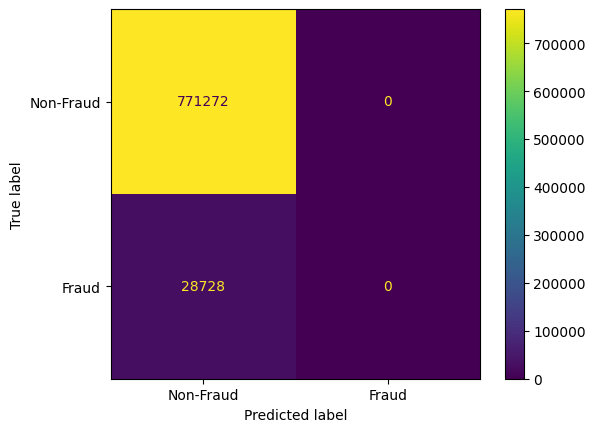

In [98]:
ConfusionMatrixDisplay.from_estimator(log_reg_baseline_model, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [99]:
print(confusion_matrix(y_val, y_pred))

[[771272      0]
 [ 28728      0]]


In [101]:
y_probs = log_reg_baseline_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')



ROC AUC Score: 0.5292
Average Precision Score: 0.0390


##### Logistic Regression (Baseline) – Evaluation

The Logistic Regression baseline model is heavily biased toward the majority class (non-fraudulent transactions). It achieves high overall accuracy (0.96), but this is misleading in the context of severe class imbalance.

The model completely fails to detect fraudulent transactions, with both precision and recall equal to 0.00 for the minority class. This means that no fraud cases are correctly identified.

The ROC AUC score (0.5292) and Average Precision score (0.0390) are only slightly above random performance, confirming that the model has almost no discriminatory power for fraud detection.

**Interpretation:**  
This model is not suitable for fraud detection in its current form, as it does not identify any minority class instances.

### Random Forest Classifier

In [106]:
# Since the Random Forest Classifier is invariant to feature scaling, we can use the preprocessing pipeline without the StandardScaler for it.
rf_clf_baseline_model = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,           # more depth to capture complex patterns
    max_features="log2",    # checks fewer features per split (faster than "sqrt")
    min_samples_leaf=100,   # prevents overly granular, slow splits      
    n_jobs=-1,              # uses all cores
    random_state=42
)
)

In [107]:
rf_clf_baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [108]:
joblib.dump(rf_clf_baseline_model, '../src/models/rf_clf_baseline_model.joblib', compress=3)

['../src/models/rf_clf_baseline_model.joblib']

In [109]:
rf_clf_baseline_model = joblib.load('../src/models/rf_clf_baseline_model.joblib')

In [110]:
y_pred = rf_clf_baseline_model.predict(X_val)

In [111]:
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   Not Fraud       0.96      1.00      0.98    771272
       Fraud       0.00      0.00      0.00     28728

    accuracy                           0.96    800000
   macro avg       0.48      0.50      0.49    800000
weighted avg       0.93      0.96      0.95    800000



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


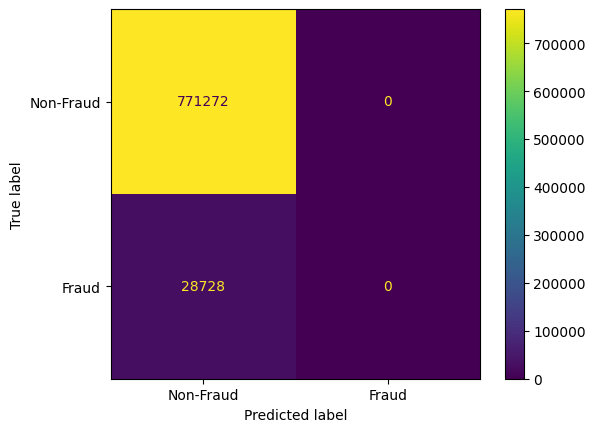

In [112]:
ConfusionMatrixDisplay.from_estimator(rf_clf_baseline_model, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [113]:
print(confusion_matrix(y_val, y_pred))

[[771272      0]
 [ 28728      0]]


In [114]:
y_probs = rf_clf_baseline_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5406
Average Precision Score: 0.0401


##### Random Forest Classifier (Baseline) – Evaluation

The Random Forest baseline model shows the same behavior as Logistic Regression, being heavily biased toward the majority class.

It achieves high accuracy (0.96), but completely fails to detect any fraudulent transactions (precision = 0.00, recall = 0.00). The confusion matrix confirms that all predictions are assigned to the non-fraud class.

The ROC AUC score (0.5406) and Average Precision score (0.0401) indicate only marginal improvement over random guessing, with no meaningful predictive power for the minority class.

**Interpretation:**  
Despite being a more complex model, Random Forest provides no improvement over Logistic Regression in the baseline setting and is not effective for fraud detection.

### Extra Trees Classifier


In [115]:
extra_trees_clf_baseline_model = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=15,
        max_features="log2",
        min_samples_leaf=100,
        n_jobs=-1,
        random_state=42
    )
)

In [116]:
extra_trees_clf_baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [117]:
joblib.dump(extra_trees_clf_baseline_model, '../src/models/extra_trees_clf_baseline_model.joblib', compress=3)

['../src/models/extra_trees_clf_baseline_model.joblib']

In [118]:
extra_trees_clf_baseline_model = joblib.load('../src/models/extra_trees_clf_baseline_model.joblib')

In [119]:
y_pred = extra_trees_clf_baseline_model.predict(X_val)

In [120]:
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   Not Fraud       0.96      1.00      0.98    771272
       Fraud       0.00      0.00      0.00     28728

    accuracy                           0.96    800000
   macro avg       0.48      0.50      0.49    800000
weighted avg       0.93      0.96      0.95    800000



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


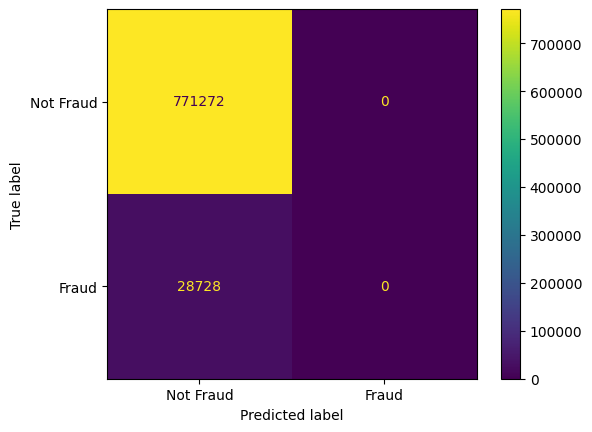

In [121]:
ConfusionMatrixDisplay.from_estimator(extra_trees_clf_baseline_model, X_val, y_val, display_labels=['Not Fraud', 'Fraud'])

In [122]:
print(confusion_matrix(y_val, y_pred))

[[771272      0]
 [ 28728      0]]


In [123]:
y_probs = extra_trees_clf_baseline_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5368
Average Precision Score: 0.0399


##### Extra Trees Classifier (Baseline) – Evaluation

The Extra Trees baseline model behaves similarly to the previous models, with a strong bias toward the majority class.

It achieves high accuracy (0.96), but fails completely to identify fraudulent transactions (precision = 0.00, recall = 0.00). The model predicts only the non-fraud class.

ROC AUC (0.5368) and Average Precision (0.0399) remain close to random performance, indicating no meaningful separation between classes.

**Interpretation:**  
The Extra Trees model does not improve upon previous baselines and is ineffective for detecting fraud in its current form.

### XGBoost Classifier

In [124]:
xgb_clf_baseline_model = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    xgb.XGBClassifier(
        n_estimators=50,
        max_depth=15,
        learning_rate=0.1,
        tree_method='hist',        # Essential: Histogram-based algorithm for speed
        max_bin=256,               # Standard binning for histograms
        min_child_weight=100,  
        n_jobs=-1,
        random_state=42,
        verbosity=1
    )
)

In [125]:
xgb_clf_baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [126]:
joblib.dump(xgb_clf_baseline_model, '../src/models/xgb_clf_baseline_model.joblib', compress=3)

['../src/models/xgb_clf_baseline_model.joblib']

In [127]:
xgb_clf_baseline_model = joblib.load('../src/models/xgb_clf_baseline_model.joblib')

In [128]:
y_pred = xgb_clf_baseline_model.predict(X_val)

In [130]:
print(classification_report(y_val, y_pred, target_names=['Non-Fraud', 'Fraud']))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

   Non-Fraud       0.96      1.00      0.98    771272
       Fraud       0.00      0.00      0.00     28728

    accuracy                           0.96    800000
   macro avg       0.48      0.50      0.49    800000
weighted avg       0.93      0.96      0.95    800000



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


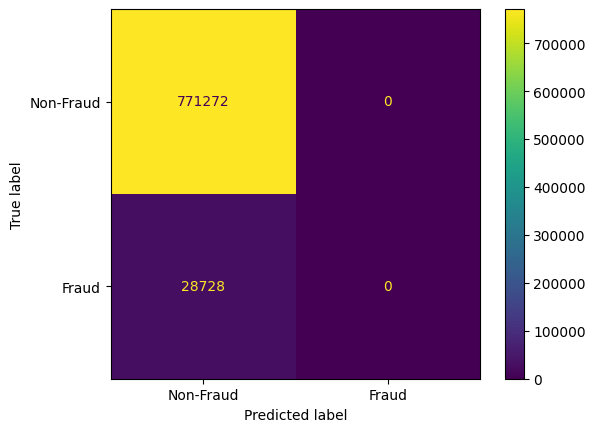

In [131]:
ConfusionMatrixDisplay.from_estimator(xgb_clf_baseline_model, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [132]:
print(confusion_matrix(y_val, y_pred))

[[771272      0]
 [ 28728      0]]


In [133]:
y_probs =  xgb_clf_baseline_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5397
Average Precision Score: 0.0399


##### XGBoost Classifier (Baseline) – Evaluation

The XGBoost baseline model shows the same pattern as all previous models, being dominated by the majority class.

Although it achieves high accuracy (0.96), it completely fails to detect fraud cases, with precision and recall both equal to 0.00.

The ROC AUC score (0.5397) and Average Precision score (0.0399) indicate only marginally better than random performance, with no practical predictive capability for the minority class.

**Interpretation:**  
Even with a powerful gradient boosting approach, the baseline XGBoost model is unable to handle the severe class imbalance and does not identify fraudulent transactions.

### Overall Baseline Model Conclusion  

All baseline models (Logistic Regression, Random Forest, Extra Trees, XGBoost) completely fail to detect fraudulent transactions, with a fraud recall of 0.00. This confirms that without any class imbalance handling, the models are heavily biased toward the majority class and are not suitable for fraud detection.

As a result, we will next explore methods for handling class imbalance and subsequently retrain the baseline models using these techniques.

## Addressing Class Imbalance

### Cost-Sensitive Learning

Before applying data-level techniques such as oversampling, we first consider a simple but effective approach: **cost-sensitive learning**. This method is computationally efficient and therefore well-suited for our large training dataset (approximately 4 million rows).  

Cost-sensitive learning operates at the model level by incorporating class weights into the loss function. Misclassifications of the minority class are assigned higher penalties, encouraging the model to prioritize correctly identifying fraudulent transactions rather than optimizing overall accuracy.  

If this approach does not sufficiently improve performance on the minority class, we will explore additional techniques such as **undersampling** or **threshold moving**. Oversampling is less suitable in this case, as it would further increase the already large dataset size.  

We will apply cost-sensitive learning to all four baseline models: **Logistic Regression**, **Random Forest**, **Extra Trees**, and **XGBoost**.

#### Logistic Regression (Cost-Sensitive)

In [134]:
log_reg_cost_sensitive = make_pipeline(
    preprocessing,
    to_float,
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs', 
        class_weight='balanced' # straightforward in scikit-learn : 
    )
)

In [135]:
log_reg_cost_sensitive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [136]:
joblib.dump(log_reg_cost_sensitive, '../src/models/log_reg_cost_sensitive.joblib', compress=3)

['../src/models/log_reg_cost_sensitive.joblib']

In [137]:
log_reg_cost_sensitive = joblib.load('../src/models/log_reg_cost_sensitive.joblib')

In [138]:
y_pred = log_reg_cost_sensitive.predict(X_val)

In [139]:
print(classification_report(y_val, y_pred, target_names=['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       0.97      0.56      0.71    771272
       Fraud       0.04      0.48      0.07     28728

    accuracy                           0.56    800000
   macro avg       0.50      0.52      0.39    800000
weighted avg       0.93      0.56      0.69    800000



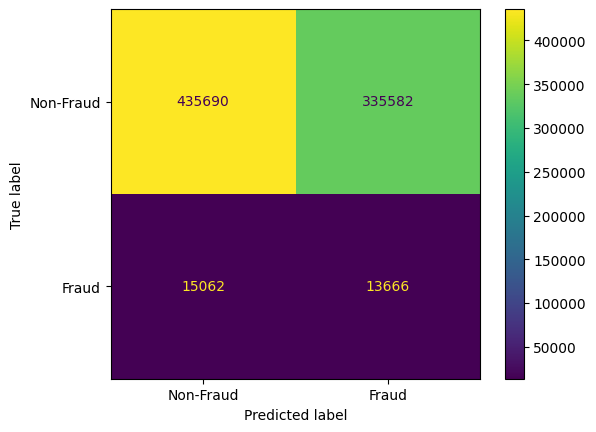

In [140]:
ConfusionMatrixDisplay.from_estimator(log_reg_cost_sensitive, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [141]:
print(confusion_matrix(y_val, y_pred))

[[435690 335582]
 [ 15062  13666]]


In [142]:
y_probs = log_reg_cost_sensitive.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5298
Average Precision Score: 0.0391


##### Logistic Regression (Cost-Sensitive) – Evaluation

With cost-sensitive learning, Logistic Regression shows a clear shift in behavior compared to the baseline model.

The model is now able to detect a meaningful portion of fraudulent transactions (recall = 0.48), whereas the baseline model failed completely in this regard. However, this improvement comes with a strong trade-off in precision (0.04), indicating a high number of false positives.

Accuracy drops significantly to 0.56, which is expected in imbalanced settings where the model is no longer biased toward the majority class.

ROC AUC (0.5298) and Average Precision (0.0391) remain almost unchanged compared to the baseline, suggesting limited improvement in overall separability.

**Interpretation:**  
Cost-sensitive learning significantly improves fraud detection capability, but introduces a strong false-positive rate. This model becomes usable for fraud detection, but remains noisy.

#### Random Forest Classifier (Cost-Sensitive)

We will now train and evaluate the **Random Forest Classifier** using `class_weight="balanced"` to handle the class imbalance, analogous to the Logistic Regression experiment.

In [143]:
rf_clf_cost_sensitive = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,           
    max_features="log2",    
    min_samples_leaf=100,   
    n_jobs=-1,   
    class_weight='balanced',           
    random_state=42
)
)

In [144]:
rf_clf_cost_sensitive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [145]:
joblib.dump(rf_clf_cost_sensitive, '../src/models/rf_clf_cost_sensitive.joblib', compress=3)

['../src/models/rf_clf_cost_sensitive.joblib']

In [146]:
rf_clf_cost_sensitive = joblib.load('../src/models/rf_clf_cost_sensitive.joblib')

In [147]:
y_pred = rf_clf_cost_sensitive.predict(X_val)

In [148]:
print(classification_report(y_val, y_pred, target_names=['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       0.97      0.70      0.81    771272
       Fraud       0.04      0.35      0.08     28728

    accuracy                           0.69    800000
   macro avg       0.50      0.53      0.44    800000
weighted avg       0.93      0.69      0.79    800000



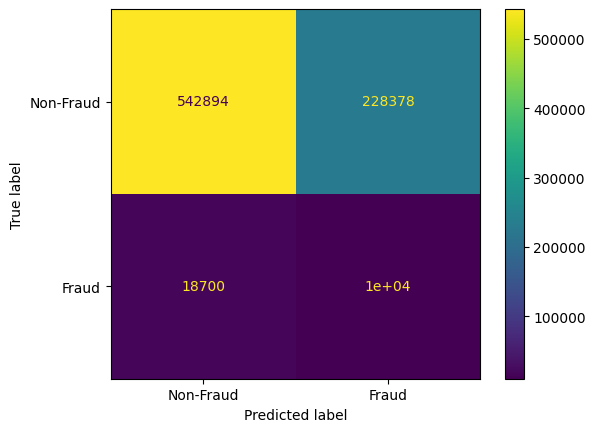

In [149]:
ConfusionMatrixDisplay.from_estimator(rf_clf_cost_sensitive, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [150]:
print(confusion_matrix(y_val, y_pred))

[[542894 228378]
 [ 18700  10028]]


In [151]:
y_probs = rf_clf_cost_sensitive.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5364
Average Precision Score: 0.0398


##### Random Forest Classifier (Cost-Sensitive) – Evaluation

The cost-sensitive Random Forest model improves significantly over its baseline version, which previously failed completely to detect fraud.

Recall for the fraud class increases to 0.35, indicating that the model now identifies a substantial number of fraudulent cases. However, precision remains very low (0.04), showing that many predictions are still false positives.

Compared to Logistic Regression (cost-sensitive), this model achieves higher accuracy (0.69) but lower fraud recall.

ROC AUC (0.5364) and Average Precision (0.0398) show only marginal improvement over random performance.

**Interpretation:**  
The model improves detection compared to its baseline, but remains less effective than Logistic Regression in identifying fraudulent transactions.

#### Extra Trees Classifier (Cost-Sensitive)

Our next step is to evaluate the **Extra Trees Classifier** using cost-sensitive learning.

In [152]:
extra_trees_clf_cost_sensitive = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=15,
        max_features="log2",
        min_samples_leaf=100,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    )
)

In [153]:
extra_trees_clf_cost_sensitive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [154]:
joblib.dump(extra_trees_clf_cost_sensitive, '../src/models/extra_trees_clf_cost_sensitive.joblib', compress=3)

['../src/models/extra_trees_clf_cost_sensitive.joblib']

In [155]:
extra_trees_clf_cost_sensitive = joblib.load('../src/models/extra_trees_clf_cost_sensitive.joblib')

In [156]:
y_pred = extra_trees_clf_cost_sensitive.predict(X_val)

In [157]:
print(classification_report(y_val, y_pred, target_names=['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       0.97      0.68      0.80    771272
       Fraud       0.04      0.37      0.07     28728

    accuracy                           0.67    800000
   macro avg       0.50      0.52      0.44    800000
weighted avg       0.93      0.67      0.77    800000



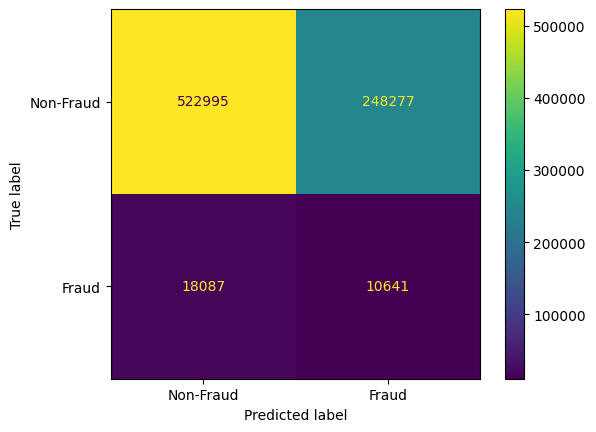

In [158]:
ConfusionMatrixDisplay.from_estimator(extra_trees_clf_cost_sensitive, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [159]:
print(confusion_matrix(y_val, y_pred))

[[522995 248277]
 [ 18087  10641]]


In [160]:
y_probs = extra_trees_clf_cost_sensitive.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5357
Average Precision Score: 0.0399


##### Extra Trees Classifier (Cost-Sensitive) – Evaluation

The Extra Trees model also benefits from cost-sensitive learning, moving from zero fraud detection in the baseline to a recall of 0.37 for the minority class.

However, precision remains extremely low (0.04), indicating a high number of false positives.

Compared to Random Forest, performance is similar, with slightly lower recall but comparable overall behavior.

ROC AUC (0.5357) and Average Precision (0.0399) remain almost unchanged, showing no meaningful improvement in ranking quality.

**Interpretation:**  
The model improves over its baseline but does not outperform Logistic Regression or Random Forest in a meaningful way for fraud detection.

#### XGBoost Classifier (Cost-Sensitive)

XGBoost does NOT have a direct class_weight parameter like sklearn.
So we have to handle class imbalance manually.

In [161]:
# --- Step 1: Count positive and negative samples ---
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)

# --- Step 2: Compute scale_pos_weight ---
# scale_pos_weight makes the minority class (here class 1) more important.
# Formula: number of negative samples / number of positive samples
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 26.846894199140227


In [162]:
# --- Step 3: Initialize XGBoost classifier ---
# Why we use this:
# XGBoost trains using gradient boosting on decision trees.
# Without weighting, the model will be biased toward the majority class.
# scale_pos_weight increases the impact of misclassifying minority class samples.
xgb_clf_cost_sensitive = make_pipeline(
    preprocessing_without_scaling,
    to_float,
    xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,  # avoids warnings in recent XGBoost versions
    objective='binary:logistic',  # standard for binary classification
    eval_metric='aucpr'  # monitor PR AUC during training
))




In [163]:
# --- Step 4: Train the model ---
xgb_clf_cost_sensitive.fit(X_train, y_train)

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:33:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [164]:
joblib.dump(xgb_clf_cost_sensitive, '../src/models/xgb_clf_cost_sensitive.joblib', compress=3)

['../src/models/xgb_clf_cost_sensitive.joblib']

In [165]:
xgb_clf_cost_sensitive = joblib.load('../src/models/xgb_clf_cost_sensitive.joblib')

In [166]:
y_pred = xgb_clf_cost_sensitive.predict(X_val)

In [167]:
print(classification_report(y_val, y_pred, target_names=['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       0.97      0.57      0.72    771272
       Fraud       0.04      0.49      0.07     28728

    accuracy                           0.57    800000
   macro avg       0.50      0.53      0.40    800000
weighted avg       0.93      0.57      0.69    800000



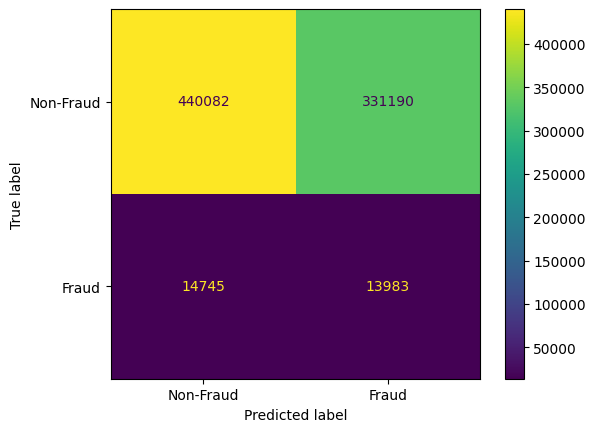

In [168]:
ConfusionMatrixDisplay.from_estimator(xgb_clf_cost_sensitive, X_val, y_val, display_labels=['Non-Fraud', 'Fraud'])

In [169]:
print(confusion_matrix(y_val, y_pred))

[[440082 331190]
 [ 14745  13983]]


In [170]:
y_probs = xgb_clf_cost_sensitive.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_probs)
print(f'ROC AUC Score: {roc_auc:.4f}')

ap_score = average_precision_score(y_val, y_probs)
print(f'Average Precision Score: {ap_score:.4f}')

ROC AUC Score: 0.5355
Average Precision Score: 0.0398


##### XGBoost Classifier (Cost-Sensitive) – Evaluation

The cost-sensitive XGBoost model shows strong improvement over its baseline, increasing fraud recall to 0.49, which the highest among all tested models.

However, this improvement comes at the cost of very low precision (0.04), indicating a large number of false positives.

Accuracy remains low (0.57), which reflects the shift away from majority-class dominance. ROC AUC (0.5355) and Average Precision (0.0398) remain nearly unchanged compared to the baseline.

**Interpretation:**  
XGBoost achieves the best fraud detection rates among all models in terms of recall, but still suffers from severe precision issues.

#### Interim Conclusion: Model Comparison (Before Advanced Imbalance Techniques)

After evaluating both baseline and cost-sensitive models, a clear pattern emerges regarding the impact of severe class imbalance on model performance.

---

Overall Observations

Applying cost-sensitive learning significantly improves performance across all models by increasing fraud recall (approximately 0.35–0.49). However, this improvement consistently comes with a strong decrease in precision, indicating a high number of false positives.

ROC AUC and Average Precision scores remain relatively low and stable across all models, suggesting limited overall separability between classes even after reweighting.

---

Current Model Behavior (Cost-Sensitive Setting)

- Logistic Regression achieves the highest fraud recall (~0.48), but with very low precision.
- XGBoost achieves comparable recall (~0.49) and is among the strongest models in detecting fraud cases.
- Random Forest and Extra Trees show more conservative behavior with lower recall (~0.35–0.37).
- All models suffer from consistently low precision (~0.04), indicating many false alarms.

---

Interim Conclusion

Cost-sensitive learning is a necessary first step and successfully demonstrates that the models can learn to detect fraud at all.

However, none of the models currently achieve a satisfactory balance between recall and precision. In particular, the high number of false positives remains a critical limitation.

---

Next Steps

To further improve performance, additional class imbalance handling techniques will be explored:

- Oversampling techniques (e.g., SMOTE)
- Comparison with cost-sensitive results
- Manual threshold tuning based on precision-recall trade-offs

Only after these steps will a final model selection be made based on a more complete evaluation.